                 folder model pretrained  max_samples    R@1   R@5   R@10
0  RN50_20250623_214602  RN50     openai         2000  53.25  78.4  88.05


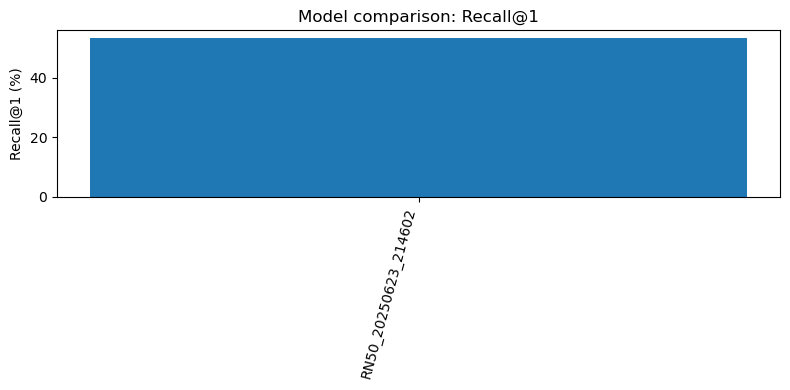

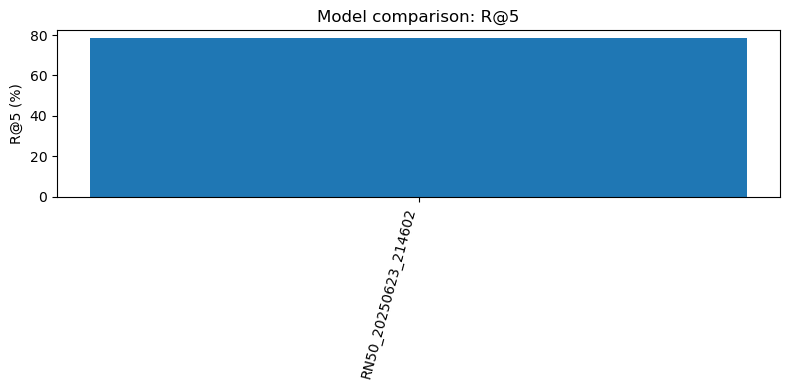

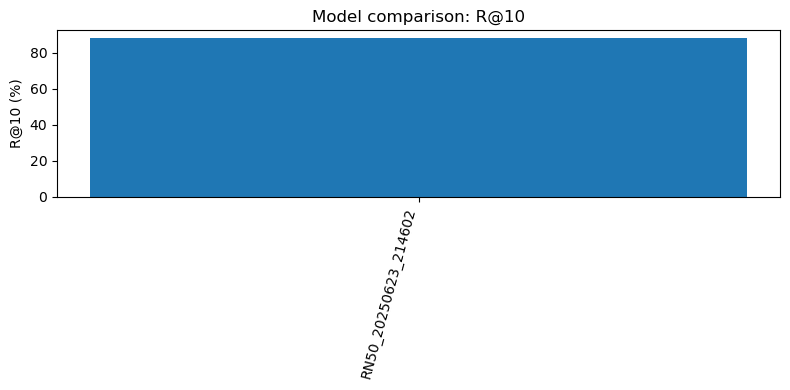

In [ ]:
# Compare retrieval performance across different model architectures or settings

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

EXP_ROOT = Path("experiments")

def load_run(p: Path):
    out = {"folder": p.name}
    for f in ["config.json", "metrics.json", "image_text_metrics.json"]:
        path = p / f
        if path.exists():
            out.update(json.loads(path.read_text()))
    return out

# Load all runs that contain valid metrics
records = []
for p in EXP_ROOT.iterdir():
    if p.is_dir() and (p / "image_text_metrics.json").exists():
        run = load_run(p)
        records.append(run)

runs_df = pd.DataFrame(records).sort_values("folder").reset_index(drop=True)

cols = ["folder", "model", "pretrained", "max_samples", "R@1", "R@5", "R@10"]
df = runs_df[cols].copy()
print(df)

# Plot Recall@1 comparison
plt.figure(figsize=(8, 4))
plt.bar(df["folder"], df["R@1"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Recall@1 (%)")
plt.title("Model comparison: Recall@1")
plt.tight_layout()
plt.show()

# Plot Recall@5 and Recall@10
for recall in ["R@5", "R@10"]:
    plt.figure(figsize=(8, 4))
    plt.bar(df["folder"], df[recall])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel(f"{recall} (%)")
    plt.title(f"Model comparison: {recall}")
    plt.tight_layout()
    plt.show()

